In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
    num1:int
    operation:str
    num2:int
    num3:int
    num4:int
    operation2:str
    final_number:int
    final_number2:int
def add_node(state: AgentState) -> AgentState:
    state["final_number"] = state["num1"] + state["num2"]
    return state

def add_node2(state: AgentState) -> AgentState:
    state["final_number2"] = state["num3"] + state["num4"]
    return state

def subtract_node(state: AgentState) -> AgentState:
    state["final_number"] = state["num1"] - state["num2"]
    return state

def subtract_node2(state: AgentState) -> AgentState:
    state["final_number2"] = state["num3"] - state["num4"]
    return state

def multiply_node(state: AgentState) -> AgentState:
    state["final_number"] = state["num1"] * state["num2"]
    return state

def multiply_node2(state: AgentState) -> AgentState:
    state["final_number2"] = state["num3"] * state["num4"]
    return state

def divide_node(state: AgentState) -> AgentState:
    state["final_number"] = state["num1"] / state["num2"]
    return state

def divide_node2(state: AgentState) -> AgentState:
    state["final_number2"] = state["num3"] / state["num4"]
    return state

In [3]:
def router1(state: AgentState) -> AgentState:
    return state
def decide_operation(state: AgentState):
    return state["operation"]

In [4]:
def router2(state: AgentState) -> AgentState:
    return state


def decide_operation2(state: AgentState):
    return state["operation2"]

In [5]:
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("router1", router1)
graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)
graph.add_node("multiply_node", multiply_node)
graph.add_node("divide_node", divide_node)

graph.add_node("router2", router2)
graph.add_node("add_node2", add_node2)
graph.add_node("subtract_node2", subtract_node2)
graph.add_node("multiply_node2", multiply_node2)
graph.add_node("divide_node2", divide_node2)


In [6]:
graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    decide_operation,
    {
        "add": "add_node",
        "subtract": "subtract_node",
        "multiply": "multiply_node",
        "divide": "divide_node",
    }
)
graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")
graph.add_edge("multiply_node", "router2")
graph.add_edge("divide_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_operation2,
    {
        "add": "add_node2",
        "subtract": "subtract_node2",
        "multiply": "multiply_node2",
        "divide": "divide_node2",
    }
)
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)
graph.add_edge("multiply_node2", END)
graph.add_edge("divide_node2", END)

app = graph.compile()

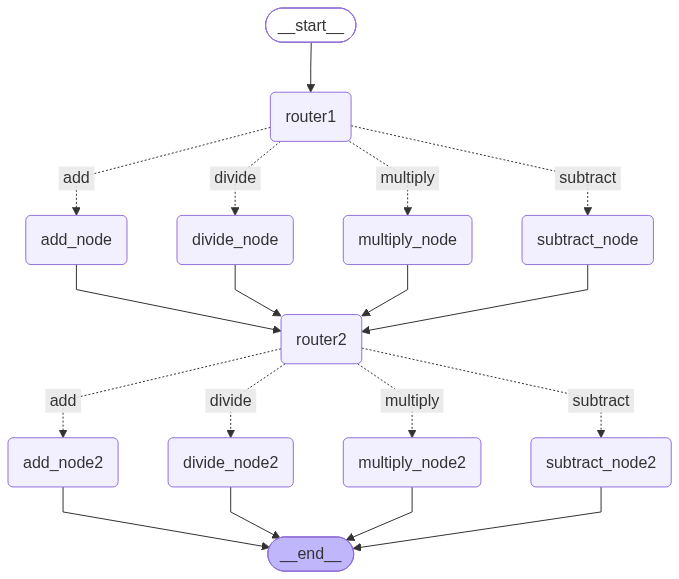

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
initial_state = {
    "num1": 10,
    "operation": "add",
    "num2": 5,
    "num3": 7,
    "num4": 2,
    "operation2": "add",
    "final_number": 0,
    "final_number2": 0
}

result = app.invoke(initial_state)

print(result)

{'num1': 10, 'operation': 'add', 'num2': 5, 'num3': 7, 'num4': 2, 'operation2': 'add', 'final_number': 15, 'final_number2': 9}
